In [1]:
import numpy as np
from matplotlib import pyplot as plt
import torch
from tqdm import tqdm

In [2]:
data=np.load('/home/kjaworski/Pulpit/Temporal_thermal_imaging/all_data_extrapolated/param_fbh_gaussian_size5mm_depth80pct_thickness6mm.npz',allow_pickle=True)
bscan=data['data'][:,200,:]
mask=data['mask'][200,:]
bscan=torch.from_numpy(bscan).float()
mask=torch.from_numpy(mask).float()

In [3]:
from helper_functions.helper_functions import d1_dy,d2_dy2


In [7]:
bscan_dy=d1_dy(bscan)
bscan_ddy=d2_dy2(bscan)

(0.0, 0.002)

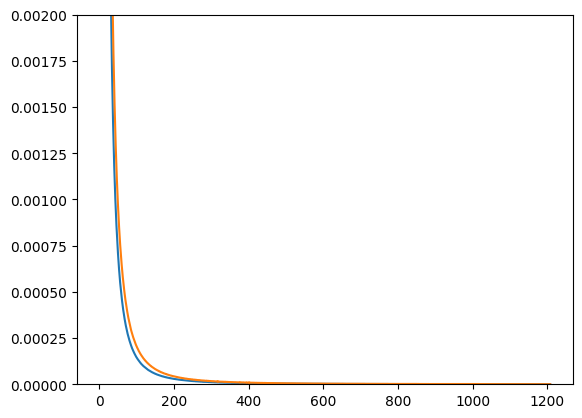

In [17]:
plt.plot(bscan_ddy[:,50])
plt.plot(bscan_ddy[:,200])
plt.ylim(0,0.002)

Text(0.5, 1.0, 'Modified ground truth')

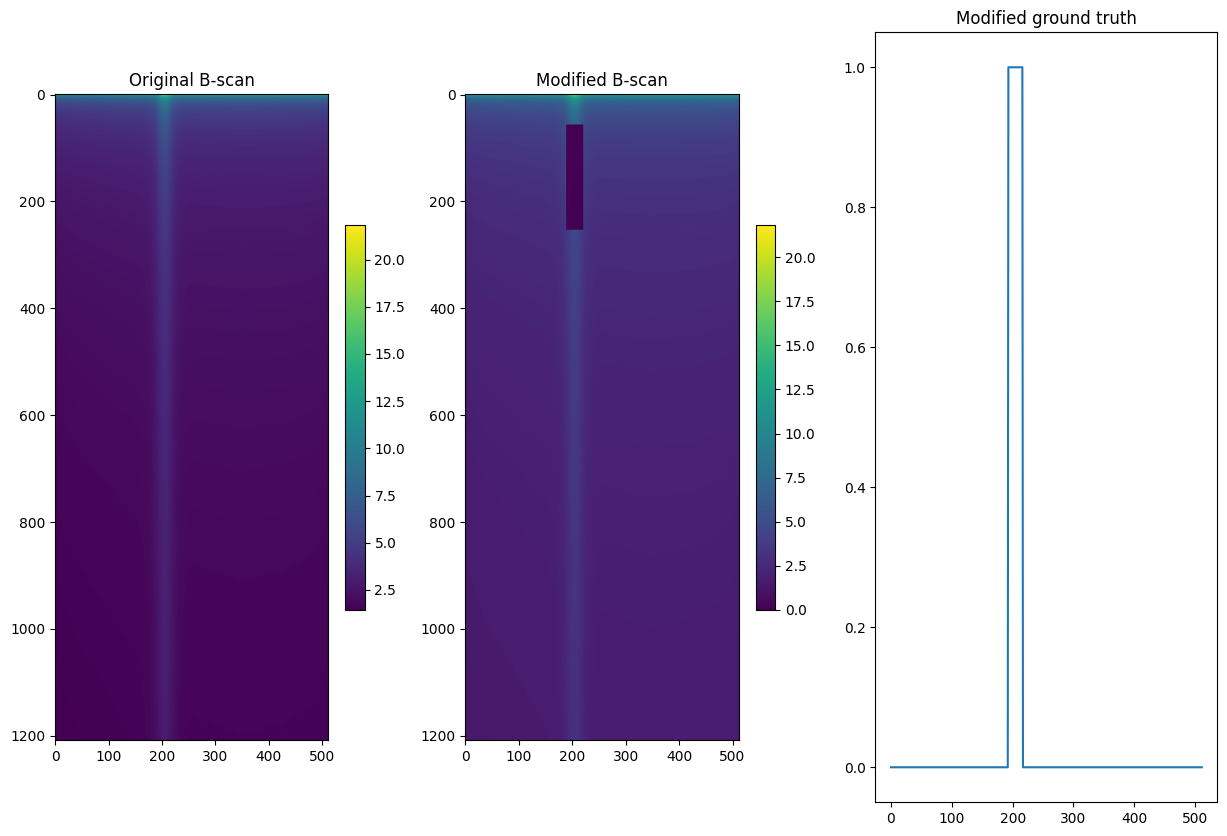

In [10]:
bscan_new,mask_new=occlusion(bscan,mask)
plt.figure(figsize=(15,10))
plt.subplot(1,3,1)
plt.imshow(bscan)
plt.title("Original B-scan")
plt.colorbar(shrink=0.5)
plt.subplot(1,3,2)
plt.imshow(bscan_new)
plt.title("Modified B-scan")
plt.colorbar(shrink=0.5)
plt.subplot(1,3,3)
plt.plot(mask_new)
plt.title('Modified ground truth')

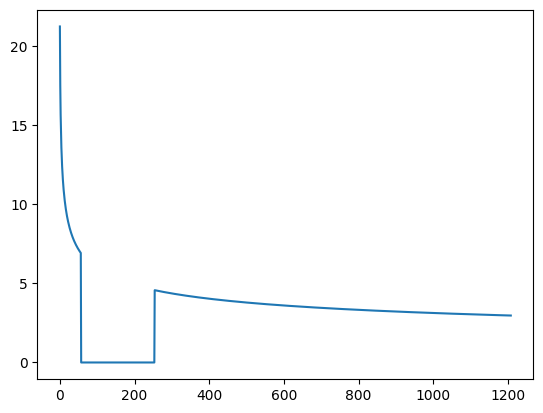

In [11]:
plt.plot(bscan_new[:,200])